In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [2]:
#### data generation
observations = 100000
xs = np.random.uniform(low = -10,high = 10, size = (observations,1))
zs = np.random.uniform(-10, 10, (observations,1))
generated_inputs = np.column_stack((xs,zs))
noise = np.random.uniform(-1, 1, (observations,1))
generated_targets = 2*xs - 3*zs + 5 + noise
np.savez('Tf_intro', inputs = generated_inputs, targets = generated_targets)

In [3]:
training_data = np.load('Tf_intro.npz')

In [4]:
input_size = 2
output_size = 1
model = tf.keras.Sequential([ 
                            tf.keras.layers.Dense(output_size,
                                                    kernel_initializer = tf.random_uniform_initializer(minval = -0.1,maxval = 0.1),
                                                    bias_initializer = tf.random_uniform_initializer(minval = -0.1, maxval = 0.1)
                                                    )
                            ])
custom_optimizer = tf.keras.optimizers.SGD(learning_rate = 0.0001)
# Fix: Use tf.keras.losses.Huber() instead of the string 'huber_loss'
model.compile(optimizer=custom_optimizer, loss=tf.keras.losses.Huber())
model.fit(training_data['inputs'], training_data['targets'], epochs=100, verbose=2)

Epoch 1/100
3125/3125 - 4s - 1ms/step - loss: 14.1203
Epoch 2/100
3125/3125 - 4s - 1ms/step - loss: 8.0254
Epoch 3/100
3125/3125 - 5s - 2ms/step - loss: 4.5645
Epoch 4/100
3125/3125 - 4s - 1ms/step - loss: 3.9311
Epoch 5/100
3125/3125 - 4s - 1ms/step - loss: 3.6148
Epoch 6/100
3125/3125 - 4s - 1ms/step - loss: 3.3041
Epoch 7/100
3125/3125 - 4s - 1ms/step - loss: 2.9940
Epoch 8/100
3125/3125 - 5s - 2ms/step - loss: 2.6841
Epoch 9/100
3125/3125 - 4s - 1ms/step - loss: 2.3744
Epoch 10/100
3125/3125 - 4s - 1ms/step - loss: 2.0650
Epoch 11/100
3125/3125 - 4s - 1ms/step - loss: 1.7561
Epoch 12/100
3125/3125 - 5s - 2ms/step - loss: 1.4483
Epoch 13/100
3125/3125 - 4s - 1ms/step - loss: 1.1461
Epoch 14/100
3125/3125 - 3s - 1ms/step - loss: 0.8735
Epoch 15/100
3125/3125 - 5s - 2ms/step - loss: 0.6507
Epoch 16/100
3125/3125 - 4s - 1ms/step - loss: 0.4825
Epoch 17/100
3125/3125 - 4s - 1ms/step - loss: 0.3643
Epoch 18/100
3125/3125 - 4s - 1ms/step - loss: 0.2860
Epoch 19/100
3125/3125 - 4s - 1ms/st

In [5]:
model.layers[0].get_weights()

[array([[ 1.9997797],
        [-3.000178 ]], dtype=float32),
 array([4.996346], dtype=float32)]

In [6]:
weights = model.layers[0].get_weights()[0]
weights

array([[ 1.9997797],
       [-3.000178 ]], dtype=float32)

In [7]:
bias = model.layers[0].get_weights()[1]
bias

array([4.996346], dtype=float32)

In [8]:
### extract the outputs/make predictions
model.predict_on_batch(training_data['inputs']).round(1)

array([[ 13. ],
       [ 13.9],
       [-15.9],
       ...,
       [ 47.1],
       [ 22.2],
       [ 30.6]], dtype=float32)

In [9]:
training_data['targets'].round(1)

array([[ 13.7],
       [ 13.3],
       [-15.9],
       ...,
       [ 46.7],
       [ 21.6],
       [ 29.9]])

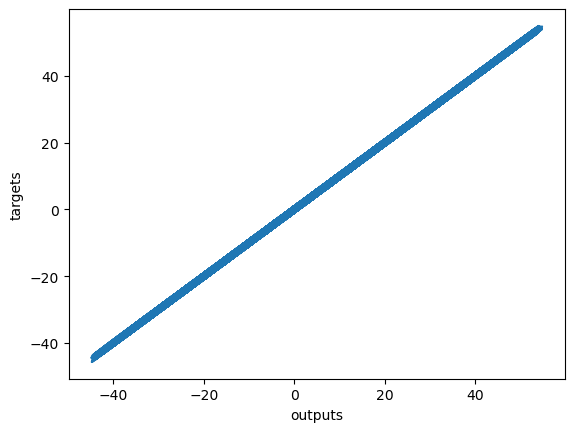

In [10]:
##### plot the data output against the targets
plt.plot(np.squeeze(model.predict_on_batch(training_data['inputs'])), np.squeeze(training_data['targets']))
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()